In [10]:


import pandas as pd
df = pd.read_csv(r'C:\Users\SIDHARTH\Downloads\Main project\books 6.csv')
df.head(5)


,Unnamed: 0,Title,review/helpfulness,review/score,review/summary,review/text,description,authors,publisher,categories,ratingsCount
0,0,From Potter's Field,0.0,5,wow real knockout great,must confess first pw like assur im go read wo...,sixth book kay scarpetta seri 1 bestsel author...,['Patricia Cornwell'],Hachette UK,Fiction,19
1,1,From Potter's Field,0.0,5,kudo kayi final saw human side,patricia cornwel final ad element dr kay scarp...,sixth book kay scarpetta seri 1 bestsel author...,['Patricia Cornwell'],Hachette UK,Fiction,19
2,2,From Potter's Field,0.0,5,im hook,ive start read book absolut wonder favorit far...,sixth book kay scarpetta seri 1 bestsel author...,['Patricia Cornwell'],Hachette UK,Fiction,19
3,3,From Potter's Field,0.0,5,one best book,never want book end one grip book ever read lu...,sixth book kay scarpetta seri 1 bestsel author...,['Patricia Cornwell'],Hachette UK,Fiction,19
4,4,From Potter's Field,0.0,2,unsatisfi end disappoint reader,plot develop nice end abruptli unsatisfi end s...,sixth book kay scarpetta seri 1 bestsel author...,['Patricia Cornwell'],Hachette UK,Fiction,19


In [11]:
df.tail(5)

,Unnamed: 0,Title,review/helpfulness,review/score,review/summary,review/text,description,authors,publisher,categories,ratingsCount
592405,1282524,Revolutionary Road,0.80,5,best book youv never heard,read book tell friend recommend book group boo...,devast effect work adulteri rebellion selfdece...,['Richard Yates'],Vintage,Fiction,17
592406,1282525,Revolutionary Road,0.75,5,american classicreview eric carlson,unsettl offput somewhat depress american novel...,devast effect work adulteri rebellion selfdece...,['Richard Yates'],Vintage,Fiction,17
592407,1282526,Revolutionary Road,0.75,5,american classic,find book prescient terribl neglect truli sham...,devast effect work adulteri rebellion selfdece...,['Richard Yates'],Vintage,Fiction,17
592408,1282527,Revolutionary Road,0.75,5,disturb geniu,dick yate best novel read prototyp best scath ...,devast effect work adulteri rebellion selfdece...,['Richard Yates'],Vintage,Fiction,17
592409,1282528,Revolutionary Road,1.00,5,surpris see hate review,grew depress like richard yate alien charact m...,devast effect work adulteri rebellion selfdece...,['Richard Yates'],Vintage,Fiction,17


In [12]:
df.shape

(592410, 11)

In [13]:
df.sample(5)


,Unnamed: 0,Title,review/helpfulness,review/score,review/summary,review/text,description,authors,publisher,categories,ratingsCount
356906,695327,Emma (Riverside Editions),0.600000,2,poor kindl edit,im write refer kindl version book sinc like bo...,content life interest marriag emma woodhous ri...,['Jane Austen'],Houghton Mifflin College Division,Language Arts & Disciplines,3
563403,1207134,Bergdorf Blondes : A Novel,1.000000,3,amus satir park avenu princess,seem exept shallow begin turn whirlwind advent...,meet moi champagn bubbl girl town work princes...,['Plum Sykes'],Bloomsbury Publishing,Fiction,31
71569,142059,Ella Enchanted,1.000000,5,love book,mom got book librari told would hate read foun...,belov newberi honorwin stori feisti heroin sur...,['Gail Carson Levine'],Harper Collins,Juvenile Fiction,210
590985,1279160,Oryx and Crake,0.500000,3,bleak futur,margaret atwood vision postapocalypt world inc...,author handmaid tale alia grace pig might fli ...,['Margaret Atwood'],Hachette UK,Fiction,301
375693,743096,Healing With Whole Foods: Oriental Traditions ...,0.983051,5,exquisit journey health whole food,quit simpli one best book ever publish subject...,use refer student acupunctur heal whole food i...,['Paul Pitchford'],North Atlantic Books,Health & Fitness,8


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 592410 entries, 0 to 592409
Data columns (total 11 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   Unnamed: 0          592410 non-null  int64  
 1   Title               592410 non-null  object 
 2   review/helpfulness  592410 non-null  float64
 3   review/score        592410 non-null  int64  
 4   review/summary      592410 non-null  object 
 5   review/text         592410 non-null  object 
 6   description         592410 non-null  object 
 7   authors             592410 non-null  object 
 8   publisher           592410 non-null  object 
 9   categories          592410 non-null  object 
 10  ratingsCount        592410 non-null  int64  
dtypes: float64(1), int64(3), object(7)
memory usage: 49.7+ MB


In [15]:
df.columns

Index(['Unnamed: 0', 'Title', 'review/helpfulness', 'review/score',
       'review/summary', 'review/text', 'description', 'authors', 'publisher',
       'categories', 'ratingsCount'],
      dtype='object')

Rating Distribution

C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


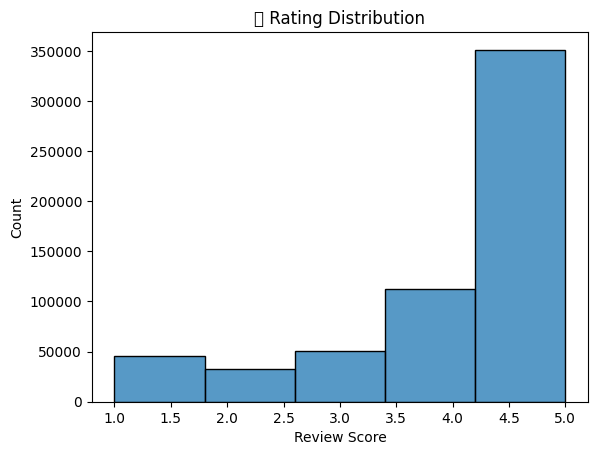

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['review/score'], bins=5)
plt.title("📈 Rating Distribution")
plt.xlabel("Review Score")
plt.ylabel("Count")
plt.show()


Word Clouds for High vs. Low Ratings

In [17]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


In [18]:
from wordcloud import WordCloud

high_reviews = df[df['review/score'] >= 4]['review/text'].dropna()
low_reviews = df[df['review/score'] <= 2]['review/text'].dropna()

WordCloud(width=800, height=400).generate(" ".join(high_reviews))
WordCloud(width=800, height=400).generate(" ".join(low_reviews))


Sentiment vs. Rating Consistency

In [19]:
pip install textBlob

Note: you may need to restart the kernel to use updated packages.


C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


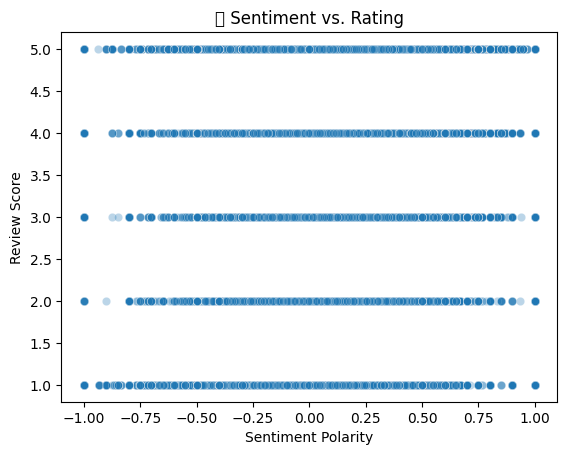

In [20]:
from textblob import TextBlob

df['sentiment'] = df['review/text'].fillna('').apply(lambda x: TextBlob(x).sentiment.polarity)

sns.scatterplot(data=df, x='sentiment', y='review/score', alpha=0.3)
plt.title("🧠 Sentiment vs. Rating")
plt.xlabel("Sentiment Polarity")
plt.ylabel("Review Score")
plt.show()


Review Length vs. Rating

In [21]:
pip install boxplot

Note: you may need to restart the kernel to use updated packages.


C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128221 (\N{MEMO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


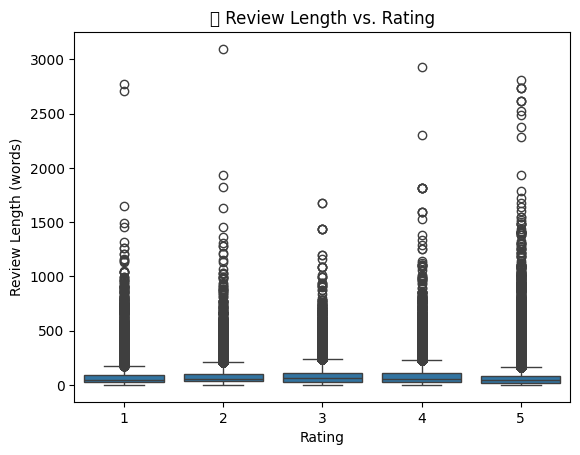

In [22]:
df['length'] = df['review/text'].fillna('').apply(lambda x: len(x.split()))

sns.boxplot(data=df, x='review/score', y='length')
plt.title("📝 Review Length vs. Rating")
plt.xlabel("Rating")
plt.ylabel("Review Length (words)")
plt.show()


Helpfulness vs. Rating

C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128077 (\N{THUMBS UP SIGN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


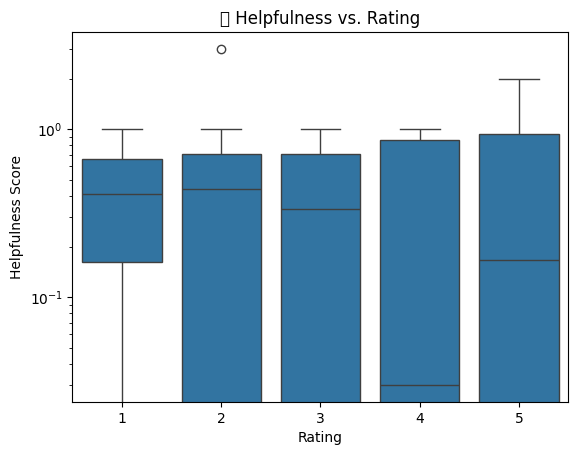

In [23]:
sns.boxplot(data=df, x='review/score', y='review/helpfulness')
plt.title("👍 Helpfulness vs. Rating")
plt.xlabel("Rating")
plt.ylabel("Helpfulness Score")
plt.yscale('log')  # Optional for skewed values
plt.show()



Category-Level Rating Trends

C:\Users\SIDHARTH\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 128218 (\N{BOOKS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


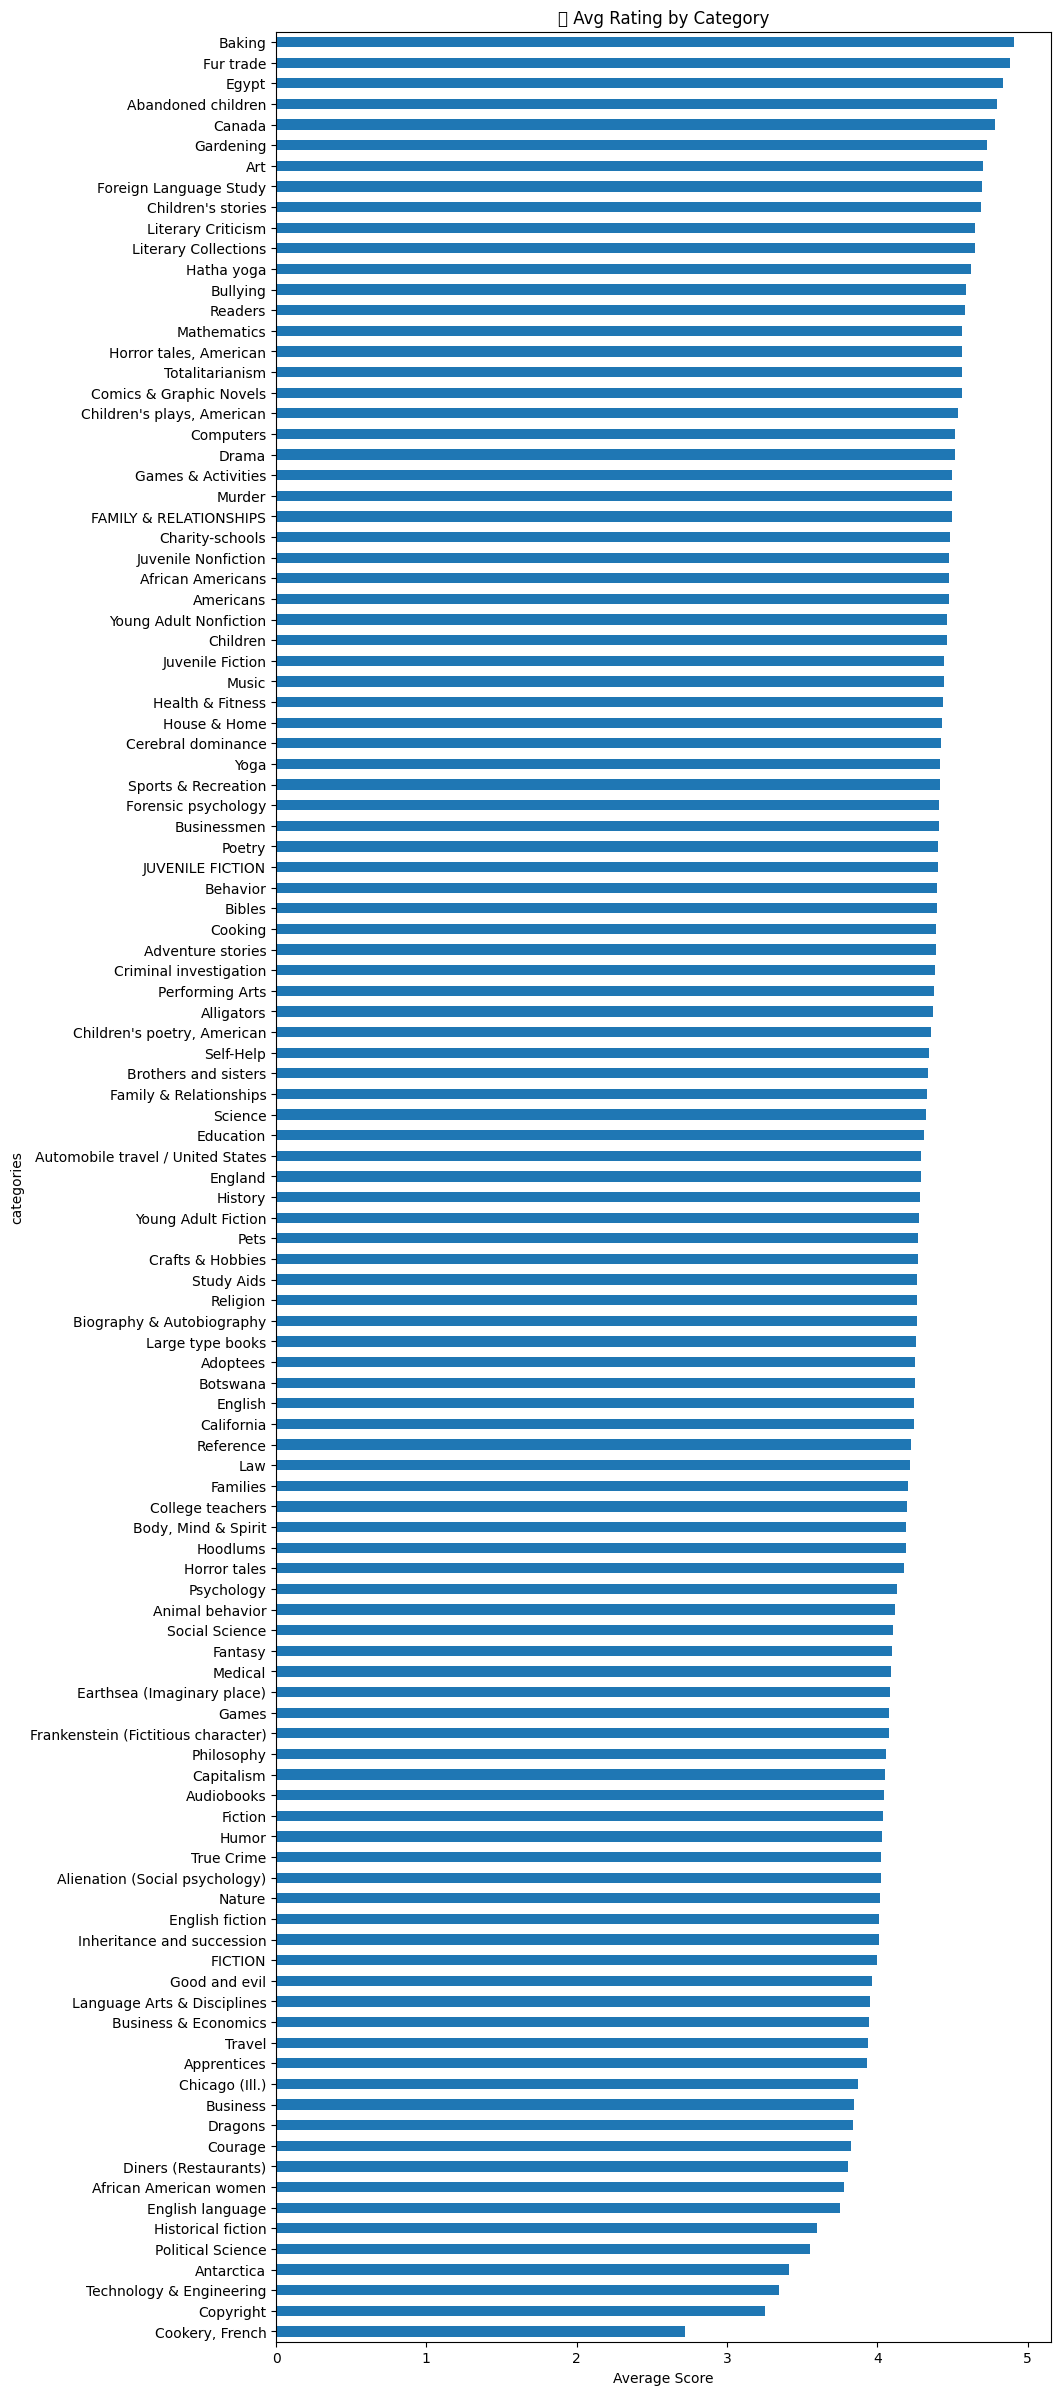

In [24]:
category_avg = df.groupby('categories')['review/score'].mean().sort_values()
category_avg.plot(kind='barh', figsize=(10, 30), title="📚 Avg Rating by Category")
plt.xlabel("Average Score")
plt.show()


In [25]:
df.drop(columns=['Unnamed: 0', 'Title', 'review/helpfulness',
       'review/summary',  'description', 'authors', 'publisher',
       'categories', 'ratingsCount' ],inplace=True)

In [26]:
df.columns

Index(['review/score', 'review/text', 'sentiment', 'length'], dtype='object')

In [27]:
df.isnull().sum()

review/score    0
review/text     0
sentiment       0
length          0
dtype: int64

In [28]:
df.dropna(inplace=True)

In [29]:
df.rename(columns={'review/text':'review','review/score':'rating'},inplace=True)

In [30]:
df.head(5)

,rating,review,sentiment,length
0,5,must confess first pw like assur im go read wo...,0.612500,30
1,5,patricia cornwel final ad element dr kay scarp...,-0.008577,84
2,5,ive start read book absolut wonder favorit far...,0.109091,31
3,5,never want book end one grip book ever read lu...,0.166667,15
4,2,plot develop nice end abruptli unsatisfi end s...,0.150000,54


In [31]:
print(df.duplicated().sum())

130068


In [32]:
df.drop_duplicates(subset=['review','rating'],inplace=True)

In [33]:
print(df.duplicated().sum())

0


In [34]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^\w\s]", "", text)
    text = re.sub(r"\d+", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df.loc[:, "review"] = df["review"].apply(clean_text)

In [35]:
df['rating']=df['rating'].astype(int)

In [36]:
df['rating'].value_counts()

rating
5    269631
4     87962
3     40703
1     37250
2     26796
Name: count, dtype: int64

In [37]:
df.shape

(462342, 4)

In [38]:
df.sample(5)

,rating,review,sentiment,length
157050,4,five peopl meet heaven mitch albom decept simp...,0.412121,52
285094,4,grip thriller warrant rave elsewher one small ...,0.092857,37
172494,4,wasnt white back outread ruckman words tsk tsk...,0.000000,9
269030,5,like book becausei like detail got better ever...,0.033333,36
448028,4,year old phantom opera modern librari version ...,0.283884,90


In [39]:
df.to_csv('D-BOOKS - 6 DL.csv',index=False)